## Prepare ReasonSeg data 

In [8]:
import os
import json

json_dir = "/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")


Extracted texts:
Total number of texts: 3408


## Apply T5-unT5

In [ ]:
from vec2text.aliases import load_model_from_alias
from transformers import AutoTokenizer
import vec2text

inversion_model_path = 'lisa_new_msmarco__msl32__100epoch'
corrector_model_path = 'lisa_new_correct_msmarco__msl32__100epoch'

inversion_model = load_model_from_alias(inversion_model_path)
corrector_model = load_model_from_alias(corrector_model_path)

corrector = vec2text.load_corrector(inversion_model, corrector_model)


lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token


import sys, copy
sys.path.append('/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break')
from sentence_optimization.emb_attack import restore_embedding

def get_embedding(text, model=inversion_model, tokenizer=lisa_tokenizer):
    inputs = tokenizer(text, return_tensors='pt', add_eos_token=True).to('cuda')
    return model.call_embedding_model(inputs['input_ids'], inputs['attention_mask'])


In [ ]:
import torch
from tqdm import tqdm

ns, sbw = None, 0
results = []

for text in tqdm(texts):
    embedding = get_embedding(text)
    restored_text = restore_embedding(embedding, corrector, ns=ns, sbw=sbw)
    results.append({
        "orig_text": text,
        "restored_text": restored_text,
        "num_steps": ns,
        "beam_width": sbw,
    })

### Save .csv

In [ ]:
import os
import json
import csv

output_csv = f"./restored_texts_ns={ns}_bsw={sbw}.csv"

if os.path.exists(output_csv):
    raise FileExistsError(f"The file '{file_path}' already exists. Please choose a different name or delete the existing file.")

print("File does not exist. Proceeding...")

with open(output_csv, mode='w', newline='', encoding='utf-8') as csvfile:
    fieldnames = ["num_steps", "beam_width", "orig_text", "restored_text"]
    writer = csv.DictWriter(csvfile, fieldnames=fieldnames)
    writer.writeheader()
    writer.writerows(results)

print(f"CSV file saved as {output_csv}")

File does not exist. Proceeding...
CSV file saved as ./restored_texts_ns=1_bsw=0.csv


### Read csv

In [ ]:
import pandas as pd

csv_file = "./restored_texts.csv"
df = pd.read_csv(csv_file)

df.head()


,num_steps,beam_width,orig_text,restored_text
0,NaN,0,If we were at the location shown in the pictur...,"If we were located in a spot on the picnic, wo..."
1,NaN,0,Suppose you are going to have a picnic at the ...,Where is the appropriate spot for laying out a...
2,NaN,0,If you were at the location shown in the pictu...,If you were located at the pits area and you w...
3,NaN,0,If we were at the location shown in the pictur...,If we were at the location where to be in the ...
4,NaN,0,Suppose we are currently at the depicted locat...,We are currently nestled and would like to put...


### Concatenate csv

In [ ]:
import os
import pandas as pd

def concatenate_csvs(input_folder, output_file):
    dataframes = []
    for file in os.listdir(input_folder):
        if file.endswith('.csv'):
            file_path = os.path.join(input_folder, file)
            print(f"Processing: {file_path}")
            df = pd.read_csv(file_path)
            dataframes.append(df)
    if dataframes:
        concatenated_df = pd.concat(dataframes, ignore_index=True)
        concatenated_df.to_csv(output_file, index=False)
        print(f"Concatenated CSV saved to: {output_file}")
    else:
        print("No CSV files found in the folder.")

In [ ]:
input_folder = "./"
output_file = "./restored_texts.csv"

concatenate_csvs(input_folder, output_file)

Processing: ./restored_texts_ns=1_bsw=0.csv
Processing: ./restored_texts_ns=None_bsw=0.csv
Processing: ./restored_texts_ns=5_bsw=5.csv
Concatenated CSV saved to: ./restored_texts.csv


## **SONAR vs LISA**

### playground

In [1]:
import sonar
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

In [ ]:
text_1 = 'Jack Morris Morris is a PhD student'
text_2 = 'It was the best of times, it was the worst of times'

In [ ]:
import numpy as np
import torch

embedding_1 = sonar_t2v.predict([text_1], source_lang="eng_Latn")[0]
embedding_2 = sonar_t2v.predict([text_2], source_lang="eng_Latn")[0]

num_interpolations = 10
interpolated_embeddings = np.linspace(embedding_1, embedding_2, num=num_interpolations)

decoded_texts = []
for embedding in interpolated_embeddings:
    decoded_text, _ = sonar_v2t.predict(torch.tensor(embedding).unsqueeze(0), target_lang="eng_Latn", max_seq_len=512)
    decoded_texts.append(decoded_text)

for i, text in enumerate(decoded_texts, start=1):
    print(f"Interpolation {i}: {text}")


Interpolation 1: ['Jack Morris Morris is a PhD student']
Interpolation 2: ['Jack Morris Morris is a PhD student']
Interpolation 3: ['Jack Morris is a PhD student']
Interpolation 4: ['Jack Morris is Jack Morris is a PhD student']
Interpolation 5: ['Jack Morris is Jack Morris was a doctor']
Interpolation 6: ['It was Best Moments, it was Best Moments']
Interpolation 7: ['It was best times, it was worst times']
Interpolation 8: ['It was the best times, it was the worst times']
Interpolation 9: ['It was the best times, it was the worst times']
Interpolation 10: ['It was the best of times, it was the worst of times']


In [ ]:
sentences = ['the landmark in Paris']
embeddings = sonar_t2v.predict(sentences, source_lang="eng_Latn")

print(embeddings.shape)

torch.Size([1, 1024])


In [ ]:
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
print(reconstructed)

['the landmark in Paris']


In [ ]:
import torch
probs = torch.exp(lprobs.T)[..., :-1]
tokens = probs.argmax(dim=0)
text = str(sonar_t2v.tokenizer.create_decoder()(tokens))
text

'the landmark in Paris'

In [ ]:
tokens

tensor([  349,  5199, 26286,   108, 20066])

In [ ]:
lisa_tokenizer.encode(text, add_special_tokens=False)

[278, 2982, 3502, 297, 3681]

In [ ]:
lisa_tokenizer.convert_tokens_to_string(text).split()

['the', 'landmark', 'in', 'Paris']

In [ ]:
probs.shape

torch.Size([256206, 5])

In [ ]:
from tqdm import tqdm
matches = {}
mis = 0
for text in tqdm(texts):
    for word in text.split():
        l_tokens = lisa_tokenizer.encode(word, add_special_tokens=False)
        s_tokens = list(sonar_t2v.tokenizer.create_encoder(lang="eng_Latn")(word)[1:-1])
        if len(l_tokens) == len(s_tokens):
            for l, s in zip(l_tokens, s_tokens):
                matches[l] = s.item()
        else:
            mis += 1

100%|██████████| 3408/3408 [00:07<00:00, 478.64it/s]


In [ ]:
len(matches)

2863

In [ ]:
lisa_probs = torch.zeros(32000, probs.shape[1])

for l_idx, s_idx in matches.items():
    lisa_probs[l_idx] = probs[s_idx]

#### gradient check

In [ ]:
import sonar, torch
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

sentences = ['the landmark in Paris very well I like that town']
embeddings = sonar_t2v.predict(sentences, source_lang="eng_Latn")

reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
reconstructed

In [ ]:
embeddings = embeddings.clone().requires_grad_()

reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
reconstructed

['the landmark in Paris very well. I like that town']

In [ ]:
lprobs_no_eos = lprobs[:-1]
lprobs_no_eos

tensor([[-14.5232,     -inf, -14.2463,  ..., -12.8552, -15.8703, -16.9058],
        [-15.0169,     -inf, -16.6157,  ..., -13.8435, -16.5867, -19.4226],
        [-13.9521,     -inf, -15.3060,  ..., -14.2813, -17.2805, -17.6962],
        ...,
        [-14.3410,     -inf, -14.7250,  ..., -14.1449, -16.8644, -19.3936],
        [-14.0555,     -inf, -14.5338,  ..., -14.2330, -17.7029, -18.8740],
        [-13.3999,     -inf, -13.8318,  ..., -12.6828, -15.7873, -17.5190]],
       grad_fn=<SliceBackward0>)

In [ ]:
lprobs_no_eos.argmax(dim=-1)

tensor([   349,   5199,  26286,    108,  20066,  15880,  14107, 248075,    117,
          6399,   1482,  68205])

In [ ]:
sonar_t2v.tokenizer.create_decoder()(lprobs_no_eos.argmax(dim=-1))

CString('the landmark in Paris very well. I like that town')

In [ ]:
import sonar, torch
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")
embeddings = torch.randn(1, 1024, requires_grad=True)

reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
reconstructed

In [ ]:
lprobs.requires_grad

False

#### reasonseg check

In [2]:
import sonar, torch
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

In [13]:
sentences = [
    'the things that a ship can hit that may cause it to run aground'
]
embeddings = sonar_t2v.predict(sentences, source_lang="eng_Latn")

In [14]:
embeddings = embeddings.clone().requires_grad_(True)

In [15]:
embeddings.shape


torch.Size([1, 1024])

In [17]:
embeddings

tensor([[ 0.0026, -0.0059, -0.0074,  ...,  0.0035,  0.0064, -0.0041]],
       requires_grad=True)

altered code

In [18]:
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
reconstructed

['the things a ship can hit that may cause it to go ashore']

In [31]:
import torch
import numpy as np

N = 20
texts = set()

for t_norm in np.arange(0.01, 0.11, 0.01):
    
    print(f'norm = {t_norm}')
    
    for _ in range(N):

        e_add = torch.randn_like(embeddings)
        e_add = t_norm * e_add / torch.norm(e_add, dim=-1, keepdim=True)

        modified_embedding = embeddings + e_add

        reconstructed_text, lprobs = sonar_v2t.predict(modified_embedding, target_lang="eng_Latn", max_seq_len=512)
        texts.add(reconstructed_text[0])
    
    print('\n')

norm = 0.01


norm = 0.02


norm = 0.03


norm = 0.04


norm = 0.05


norm = 0.060000000000000005


norm = 0.06999999999999999


norm = 0.08


norm = 0.09


norm = 0.09999999999999999




In [30]:
reconstructed_text

['the things a ship can hit that may cause it to go ashore']

In [28]:
import torch
import numpy as np

N = 10
t_norm = 0.05  # Fixed norm for e_add
angles = np.arange(0, 181, 10)  # Angles from 0 to 180 degrees

for angle in angles:
    print(f'Angle = {angle} degrees')
    
    for _ in range(N):
        e_add = torch.randn_like(embeddings)
        e_add = e_add / torch.norm(e_add, dim=-1, keepdim=True)
        
        cos_theta = np.cos(np.radians(angle))
        
        projection = torch.sum(embeddings * e_add, dim=-1, keepdim=True) * e_add
        
        orthogonal_component = embeddings - projection
        
        orthogonal_component = orthogonal_component / torch.norm(orthogonal_component, dim=-1, keepdim=True)
        
        e_add = cos_theta * e_add + np.sqrt(1 - cos_theta**2) * orthogonal_component
        
        e_add = t_norm * e_add
        
        modified_embedding = embeddings + e_add

        reconstructed_text, lprobs = sonar_v2t.predict(modified_embedding, target_lang="eng_Latn", max_seq_len=512)
        print(reconstructed_text)
    
    print('\n')

Angle = 0 degrees
['the things that a ship can hit which may cause it to go ashore']
['the things a ship can hit which may cause it to run ashore']
['the things that a ship can hit which may cause it to go ashore']
['the things a ship can hit that may cause it to run ashore']
['the things that a ship can hit that may cause it to go ashore']
['the things a ship can hit that may cause it to go ashore']
['the things a ship can hit that may cause it to go ashore']
['the things that a ship can hit that may cause it to go ashore']
['the things a ship can hit which can cause it to go ashore']
['the things a ship can hit which may cause it to run ashore']


Angle = 10 degrees
['the things that a ship can hit which can cause it to go ashore']
['the things a a ship can hit that may cause it to go ashore']
['the things a ship can hit that may cause it to go ashore']
['the things a ship can hit that can cause it to run ashore']
['the things that a ship can hit that may cause it to run ashore']
['t

In [ ]:
'the things that a ship can hit that may cause it to run aground'

original code

In [3]:
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
reconstructed

['I can embed the sentences into vector space.']

#### decode SONAR tokens

In [33]:
sonar_t2v.tokenizer.create_decoder()(lprobs.argmax(dim=-1))

CString('I can embbed the sentences into vector space.')

### **load texts**

In [3]:
import os
import json

json_dir = "/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test"

texts = []

for filename in os.listdir(json_dir):
    if filename.endswith(".json"):
        file_path = os.path.join(json_dir, filename)
        with open(file_path, 'r') as f:
            data = json.load(f)
            if "text" in data:
                texts.extend(data["text"])

print("Extracted texts:")
print(f"Total number of texts: {len(texts)}")


Extracted texts:
Total number of texts: 3408


### **transition: LISA and SONAR**

In [1]:
import sys
sys.path.append('/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break')

In [2]:
from sentence_optimization.model_setup import setup_model, setup_tokenizer

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(
/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/transformers/utils/generic.py:311: UserWarning: torch.utils._pytree._register_pytree_node is deprecated. Please use torch.utils._pytree.register_pytree_node instead.
  torch.utils._pytree._register_pytree_node(


In [3]:
import sonar
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

sonar_tokenizer = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')

In [5]:
sonar_decoder = sonar_t2v.tokenizer.create_decoder()

In [7]:
import torch
sonar_decoder(torch.tensor([1590]))

CString('tion')

In [28]:
reversed_lisa_vocab = {v: k for k, v in lisa_tokenizer.get_vocab().items()}
lisa_vocab = lisa_tokenizer.get_vocab()

In [29]:
reversed_lisa_vocab[292]

'ing'

In [31]:
reversed_lisa_vocab[2348]

'▁ing'

In [8]:
sonar_tokenizer.encode_as_tokens('belongings')[1:-1]

[CString('▁belong'), CString('ings')]

In [21]:
lisa_tokenizer.encode('What is coloring', add_special_tokens=False)

[1724, 338, 2927, 292]

In [35]:
words = 'What is coloring'.split()
words

['What', 'is', 'coloring']

In [37]:
lisa_tokenizer.encode('color', add_special_tokens=False)

[2927]

In [34]:
lisa_tokenizer.encode('!ing', add_special_tokens=False)

[1738, 292]

In [44]:
words = 'What is coloring'.split()
result = any(word.startswith('What') for word in words)
print(result)  # Output: True

True


In [23]:
sonar_tokenizer('▁reduc')[1:-1]

tensor([32707])

In [27]:
sonar_tokenizer('tion')[1:-1]

tensor([67279,  1590])

In [10]:
from transformers import AutoTokenizer

lisa_tokenizer = AutoTokenizer.from_pretrained(
    "xinlai/LISA-13B-llama2-v1",
    use_fast=False,
    add_eos_token=True
)
lisa_tokenizer.pad_token = lisa_tokenizer.unk_token

/home/jovyan/soshin/envs/zinkovich-sonar/lib/python3.11/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [ ]:
from tqdm import tqdm

unique_tokens = {}

for text in tqdm(texts):
    lisa_tokens = lisa_tokenizer(text)['input_ids']
    for t in lisa_tokens:
        unique_tokens.add(t)

100%|██████████| 3408/3408 [00:00<00:00, 4611.69it/s]


In [9]:
from tqdm import tqdm

s_unique_tokens = set()

for text in tqdm(texts):
    sonar_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text).detach().cpu().numpy()
    for t in sonar_tokens:
        s_unique_tokens.add(t)

100%|██████████| 3408/3408 [00:00<00:00, 9208.35it/s]


In [10]:
len(unique_tokens), len(s_unique_tokens)

(3797, 3731)

#### tokenizer transition

In [24]:
lisa_tokenizer.get_vocab()

{'<unk>': 0,
 '<s>': 1,
 '</s>': 2,
 '<0x00>': 3,
 '<0x01>': 4,
 '<0x02>': 5,
 '<0x03>': 6,
 '<0x04>': 7,
 '<0x05>': 8,
 '<0x06>': 9,
 '<0x07>': 10,
 '<0x08>': 11,
 '<0x09>': 12,
 '<0x0A>': 13,
 '<0x0B>': 14,
 '<0x0C>': 15,
 '<0x0D>': 16,
 '<0x0E>': 17,
 '<0x0F>': 18,
 '<0x10>': 19,
 '<0x11>': 20,
 '<0x12>': 21,
 '<0x13>': 22,
 '<0x14>': 23,
 '<0x15>': 24,
 '<0x16>': 25,
 '<0x17>': 26,
 '<0x18>': 27,
 '<0x19>': 28,
 '<0x1A>': 29,
 '<0x1B>': 30,
 '<0x1C>': 31,
 '<0x1D>': 32,
 '<0x1E>': 33,
 '<0x1F>': 34,
 '<0x20>': 35,
 '<0x21>': 36,
 '<0x22>': 37,
 '<0x23>': 38,
 '<0x24>': 39,
 '<0x25>': 40,
 '<0x26>': 41,
 '<0x27>': 42,
 '<0x28>': 43,
 '<0x29>': 44,
 '<0x2A>': 45,
 '<0x2B>': 46,
 '<0x2C>': 47,
 '<0x2D>': 48,
 '<0x2E>': 49,
 '<0x2F>': 50,
 '<0x30>': 51,
 '<0x31>': 52,
 '<0x32>': 53,
 '<0x33>': 54,
 '<0x34>': 55,
 '<0x35>': 56,
 '<0x36>': 57,
 '<0x37>': 58,
 '<0x38>': 59,
 '<0x39>': 60,
 '<0x3A>': 61,
 '<0x3B>': 62,
 '<0x3C>': 63,
 '<0x3D>': 64,
 '<0x3E>': 65,
 '<0x3F>': 66,
 '<0x40>': 

In [35]:
sonar_tokenizer('ally')[1:-1]

tensor([235, 924])

In [36]:
sonar_tokenizer.encode_as_tokens('ally')

[CString('__eng_Latn__'), CString('▁al'), CString('ly'), CString('</s>')]

In [87]:
matches = {}
unmatched = {}

for text in tqdm(texts):
    for word in text.split():
        l_tokens = lisa_tokenizer.encode(word, add_special_tokens=False)
        s_tokens = list(sonar_tokenizer(word)[1:-1])
        if len(l_tokens) == len(s_tokens):
            for l, s in zip(l_tokens, s_tokens):
                matches[l] = s.item()
        elif len(l_tokens) == 1:
            matches[l_tokens[0]] = s_tokens[0].item()
        # elif len(s_tokens) == 1:
        #     matches[l_tokens[0]] = s_tokens[0].item()
        # else: 
        #     unmatched[l_tokens[0]] = (reversed_lisa_vocab[l_tokens[0]], word, l_tokens, s_tokens)
            

100%|██████████| 3408/3408 [00:06<00:00, 531.72it/s]


In [82]:
unmatched[304]

('▁to', 'toy', [304, 29891], [tensor(16202)])

In [84]:
lisa_tokenizer('toy', add_special_tokens=False)['input_ids'], sonar_tokenizer('toy')[1:-1]

([304, 29891], tensor([16202]))

In [74]:
unmatched

{28326: '▁feas',
 1401: '▁dep',
 5870: '▁meet',
 2011: '▁port',
 3618: '▁objects',
 13230: '▁troops',
 13936: '▁soldiers',
 28965: '▁racing',
 25688: '▁overcome',
 24147: '▁movements',
 7618: '▁cru',
 640: '▁cont',
 2166: '▁Su',
 16778: '▁roots',
 10503: '▁surv',
 23136: '▁environments',
 11785: '▁bright',
 17443: '▁characteristic',
 304: '▁to',
 2130: '▁access',
 7245: '▁lug',
 15252: '▁furn',
 7561: '▁Tod',
 8388: '▁surr',
 427: '▁en',
 26987: '▁explore',
 4837: '▁vert',
 3347: '▁brow',
 9262: '▁selection',
 678: '▁Ch',
 521: '▁ch',
 867: '▁gr',
 274: '▁c',
 270: '▁d',
 15243: '▁ton',
 288: '▁o',
 592: '▁me',
 14060: '▁expos',
 1424: '▁fr',
 5330: '▁ign',
 24400: '▁landscape',
 330: '▁g',
 25672: '▁ceremony',
 5147: '▁cer',
 20255: '▁assistant',
 591: '▁we',
 20444: '▁iv',
 6683: '▁spect',
 263: '▁a',
 7911: '▁ty',
 6592: '▁bed',
 12234: '▁typically',
 22832: '▁affection',
 17354: '▁brown',
 8939: '▁ped',
 23511: '▁safely',
 22039: '▁partially',
 9427: '▁fish',
 2351: '▁mov',
 1704: 

In [53]:
word

'feasible'

In [78]:
sonar_tokenizer.encode_as_tokens('▁to')[1:-1]

[CString('▁to')]

In [64]:
[reversed_lisa_vocab[token] for token in l_tokens]

['▁feas', 'ible']

In [67]:
sonar_tokenizer.encode_as_tokens('ible')[1:-1]

[CString('▁ib'), CString('le')]

In [86]:
print(f'{len(matches)} out of {len(unique_tokens)}, p = {len(matches)/len(unique_tokens):.2f} %')

3379 out of 3797, p = 0.89 %


#### **same tokens**

In [61]:
reversed_lisa_vocab = {v: k for k, v in lisa_tokenizer.get_vocab().items()}
lisa_vocab = lisa_tokenizer.get_vocab()

In [ ]:
rs_lisa_vocab = {}

for token in unique_tokens:
    rs_lisa_vocab[reversed_lisa_vocab[token]] = token

In [ ]:
rs_sonar_vocab = {}

for text in tqdm(texts):
    s_subwords = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn').encode_as_tokens(text)
    s_subwords = list(map(str, s_subwords))
    s_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text).detach().cpu().numpy()
    
    for t, sbwrd in zip(s_tokens, s_subwords):
        rs_sonar_vocab[sbwrd] = t

100%|██████████| 3408/3408 [00:00<00:00, 4478.51it/s]


In [ ]:
len(rs_sonar_vocab), len(rs_lisa_vocab)

(3731, 3797)

In [ ]:
matched_keys = set(rs_sonar_vocab.keys()) & set(rs_lisa_vocab.keys())
num_matched_keys = len(matched_keys)

print(f"Matched keys: {matched_keys}")
print(f"Number of matched keys: {num_matched_keys}") 

Matched keys: {'▁saf', '▁sens', 'ten', '▁specific', '▁mouth', '▁object', '▁player', '▁could', 'line', '▁br', '▁leadership', '▁Ped', '▁building', '▁appe', '▁offer', 'car', '▁became', 'ar', '▁app', '▁and', '▁be', '▁form', '▁way', '▁I', '▁trip', '▁regular', '▁war', 'aren', '▁style', '▁prices', 'bers', '▁experienced', 'power', '▁speech', '▁feeling', '▁infer', '▁add', 'atic', '▁Ch', '▁marks', '▁where', '▁notification', '▁comfortable', 'wind', '▁summer', '▁to', '▁event', '▁result', 'ks', '▁keep', '▁site', '▁commercial', '▁face', '▁cup', '▁your', '▁relevant', '▁nap', '▁roof', '▁on', '▁matter', '▁library', '▁young', '▁comes', '▁shot', '▁therefore', '是', '▁called', '▁quickly', '▁types', '▁dust', '▁Which', '▁cultural', '▁blo', '▁student', '▁determined', 'vest', '▁level', '▁inj', 'ede', '▁seat', 'ps', '▁season', '▁affected', '▁hidden', '▁offers', '▁helps', 'pack', '▁article', '▁potential', 'ores', '▁fit', '▁fun', '▁race', '▁From', '▁icon', 'mit', '上', 'ake', '▁leading', '▁fallen', '▁quite', 'ins'

In [ ]:
unmatched_in_sonar = set(rs_sonar_vocab.keys()) - set(rs_lisa_vocab.keys())
unmatched_in_lisa = set(rs_lisa_vocab.keys()) - set(rs_sonar_vocab.keys())

print(f"Unmatched tokens in sonar: {unmatched_in_sonar}")
print(f"Unmatched tokens in lisa: {unmatched_in_lisa}") 

Unmatched tokens in sonar: {'▁attemp', 'ennis', 'ele', '▁Pizza', '▁amazing', 'ni', '▁academ', '▁sco', '▁healthy', '▁Potter', 'pas', '▁categori', 'cov', 'hle', '▁bene', '▁Butter', '▁den', '▁cong', '▁distin', 'vate', '▁obje', '▁ultim', '▁selfie', 'ugg', '▁coo', '▁valua', '▁dela', 'fice', '▁lawn', '▁produc', 'lash', '▁accom', '▁alcohol', 'hen', 'yed', '▁nour', '▁gest', '▁swi', '▁supplement', '▁reser', 'tional', 'ken', 'gh', 'ump', 'isit', '▁viola', 'omo', '▁wo', 'mon', 'cados', 'cher', '▁mi', 'rates', '▁birthday', 'fere', '▁immer', 'adow', 'enter', '▁wi', '▁venti', 'ty', '▁orient', '▁chi', 'cyc', '▁bacteri', 'itals', 'erta', 'ism', 'hibition', 'tle', '▁spro', '▁ke', '▁Dri', '▁bite', 'sion', '▁spar', '▁recogni', 'holic', 'oval', '▁mim', 'ping', '▁pit', '▁enta', '▁plat', '▁expres', '▁gent', '▁有', 'cular', '▁portr', 'engers', 'venti', '▁foods', '▁balan', '▁temperatures', '▁li', 'ila', '▁G', '▁Hotels', '▁contr', '▁obsta', '▁agreements', 'isine', 'usias', 'tions', '▁festi', 'ople', '▁juice', '

#### **tokens match**

In [ ]:
len(unmatched_in_sonar), len(unmatched_in_lisa)

(1154, 1220)

In [ ]:
sum("▁" in element for element in unmatched_in_lisa)


778

In [ ]:
sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')('生')

tensor([256047,  64207,      3])

In [ ]:
sonar_t2v.tokenizer.create_encoder(lang='eng_Latn').encode_as_tokens('生')

[CString('__eng_Latn__'), CString('▁生'), CString('</s>')]

In [ ]:
ucount = sum("▁" in element for element in my_set)
nmatched_in_lisa

{'▁holes',
 '▁interact',
 'redu',
 '生',
 '▁terrain',
 'uff',
 '▁modify',
 '▁implementing',
 '▁rout',
 '▁perm',
 'greg',
 'uck',
 'lections',
 'acter',
 '▁brown',
 '▁indicating',
 '▁amaz',
 'ach',
 '▁attempts',
 '▁ceremony',
 '▁passing',
 '<0x80>',
 '▁spl',
 '▁Assuming',
 '<0xAA>',
 'famil',
 '▁Hall',
 'ference',
 'icles',
 'rows',
 'urable',
 '▁sizes',
 '<0xE4>',
 '▁documentation',
 '么',
 '▁wrapping',
 '▁Te',
 '▁desired',
 '▁landscape',
 'ession',
 'books',
 '▁ign',
 'riors',
 '▁blue',
 '▁thorough',
 '▁consume',
 '<0xE5>',
 '▁Hel',
 '▁Car',
 '▁academic',
 '▁para',
 '物',
 '▁neighborhood',
 '▁ampl',
 '▁pers',
 '▁purs',
 '▁tracks',
 'ound',
 'aching',
 '▁festiv',
 '▁departure',
 '▁accurate',
 'iff',
 'itime',
 '▁curious',
 '▁intellig',
 'ably',
 'utter',
 '▁employed',
 '▁designated',
 '▁belief',
 'icken',
 '▁del',
 'acy',
 'port',
 '▁Ve',
 '▁featuring',
 '▁rit',
 'ually',
 '▁casting',
 '▁autom',
 '▁horses',
 'izard',
 '▁fr',
 'icate',
 '▁resulting',
 'gr',
 '▁aff',
 '▁stad',
 '▁emp',
 '▁c

In [93]:
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

In [94]:
sonar_tokenizer = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')

In [ ]:
t_tokens = self.sonar_tokenizer(gen_output.text)[1:-1]
s_one_hot = torch.zeros((len(t_tokens), self.sonar_embeds.shape[0]))
s_one_hot[torch.arange(len(t_tokens)), t_tokens] = 1

## **Find pseudoinverse**

In [7]:
import yaml

class CfgDict:
    def __init__(self, cfg_dict):
        for key, value in cfg_dict.items():
            setattr(self, key, value)

with open("/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/configs/segmod/liza.yaml", "r") as file:
    cfg_dict = yaml.safe_load(file)

cfg = CfgDict(cfg_dict)

In [8]:
model = setup_model(cfg, lisa_tokenizer, device='cuda')

{'ce_loss_weight': 1.0, 'dice_loss_weight': 0.5, 'bce_loss_weight': 2.0, 'use_mm_start_end': True, 'seg_token_idx': 32000}
LlavaConfig {
  "_name_or_path": "xinlai/LISA-13B-llama2-v1",
  "architectures": [
    "LISAForCausalLM"
  ],
  "bos_token_id": 1,
  "eos_token_id": 2,
  "freeze_mm_mlp_adapter": true,
  "hidden_act": "silu",
  "hidden_size": 5120,
  "image_aspect_ratio": "square",
  "image_grid_pinpoints": null,
  "initializer_range": 0.02,
  "intermediate_size": 13824,
  "max_position_embeddings": 4096,
  "mm_hidden_size": 1024,
  "mm_resampler_type": null,
  "mm_use_im_patch_token": false,
  "mm_use_im_start_end": true,
  "mm_vision_select_feature": "patch",
  "mm_vision_select_layer": -2,
  "mm_vision_tower": "openai/clip-vit-large-patch14",
  "model_type": "llava",
  "num_attention_heads": 40,
  "num_hidden_layers": 40,
  "num_key_value_heads": 40,
  "out_dim": 256,
  "pad_token_id": 0,
  "pretrain_mm_mlp_adapter": null,
  "pretraining_tp": 1,
  "rms_norm_eps": 1e-05,
  "rope_

Loading checkpoint shards:   0%|          | 0/3 [00:00<?, ?it/s]

You are resizing the embedding layer without providing a `pad_to_multiple_of` parameter. This means that the new embedding dimension will be 32003. This might induce some performance reduction as *Tensor Cores* will not be available. For more details about this, or help on choosing the correct value for resizing, refer to this guide: https://docs.nvidia.com/deeplearning/performance/dl-performance-matrix-multiplication/index.html#requirements-tc


In [9]:
import torch 
with torch.no_grad():
    lisa_embeddings = model.get_input_embeddings().weight.float()

In [14]:
text = 'engines for this plane'
s_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text)[1:-1]
l_tokens = lisa_tokenizer.encode(text, add_special_tokens=False)

In [15]:
s_tokens, l_tokens

(tensor([ 2344,  7234,   351,  3423, 42206]), [24000, 363, 445, 10694])

In [16]:
l_embs = lisa_embeddings[l_tokens]
l_embs.shape

torch.Size([4, 5120])

In [17]:
sonar_embeddings = sonar_t2v.model.encoder_frontend.embed.weight
s_embs = sonar_embeddings[s_tokens]
s_embs.shape

torch.Size([5, 1024])

In [25]:
sonar_embeddings = sonar_t2v.model.encoder_frontend.embed.weight
rs_sonar_embs = sonar_embeddings[list(s_unique_tokens)]
rs_sonar_embs.shape

torch.Size([3731, 1024])

In [41]:
rs_lisa_embs = lisa_embeddings[list(unique_tokens)]
rs_lisa_embs.shape

torch.Size([3797, 5120])

In [159]:
unique_tokens_list = list(unique_tokens)
len(unique_tokens_list)

3797

#### Pseudoinverse between each pairs

In [11]:
import numpy as np
import torch
from sklearn.decomposition import PCA

unique_embeddings = lisa_embeddings[list(unique_tokens)].cpu()

pca = PCA(n_components=1024)
unique_embeddings_reduced = pca.fit_transform(unique_embeddings)
unique_embeddings_reduced = torch.tensor(unique_embeddings_reduced)

# l_embeds = lisa_embeddings[l_tokens].cpu().numpy()
# l_embeds_reduced = pca.transform(l_embeds)
# l_embeds_reduced = torch.tensor(l_embeds_reduced) 

# print("Final transformed embeddings shape:", l_embeds_reduced.shape)


In [20]:
import numpy as np
import torch

# Convert to numpy for SVD
l_embeds_reduced_np = l_embeds_reduced.detach().numpy()
s_embs_np = s_embs.detach().numpy()

# Compute SVD on l_embeds_reduced^T @ s_embs
U, Sigma, Vt = np.linalg.svd(l_embeds_reduced_np @ s_embs_np.T, full_matrices=False)
print(f'condition number: {Sigma.max() / Sigma.min()}')

# Reconstruct the transformation matrix T
T = U @ np.diag(Sigma) @ Vt

# Apply the transformation
s_embs_approx = T.T @ l_embeds_reduced_np

error = np.linalg.norm(s_embs_np - s_embs_approx)
print(f"Approximation error: {error}")


condition number: 6.612711393054724
Approximation error: 26.44431433715867


In [ ]:
import torch

# Example LISA and SONAR embeddings (replace with your actual tensors)
E_SONAR = s_embs.cpu().float()

# Step 2: Transpose for matrix computation
E_LISA_T = l_embeds_reduced.T.float() 
E_SONAR_T = E_SONAR.T.float()        

# Step 3: Compute transition matrix using Moore-Penrose pseudoinverse
T = E_SONAR @ E_LISA_T @ torch.linalg.pinv(E_LISA_T.T @ E_LISA_T)

print("Transition matrix shape:", T.shape)

# Step 4: Compute SONAR approximation
E_SONAR_approx = T @ E_LISA_T.T  # Approximation of SONAR

# Step 5: Compute approximation error
error = torch.norm(E_SONAR - E_SONAR_approx, p='fro')  # Frobenius norm
print("Approximation error (Frobenius norm):", error.item())


Transition matrix shape: torch.Size([5, 4])
Approximation error (Frobenius norm): 26.401660919189453


In [115]:
# Step 6: Compute the condition number of the transition matrix
# Calculate the singular values of T
U, S, V = torch.svd(T)
# Singular values are in the diagonal matrix S, get the max and min singular values
sigma_max = S.max().item()
sigma_min = S.min().item()

# Compute the condition number
condition_number = sigma_max / sigma_min
print("Condition number of the transition matrix:", "{:.1e}".format(condition_number))

Condition number of the transition matrix: 2.0e+01


#### Pseudoinverse between all

In [12]:
import numpy as np
import torch
from sklearn.decomposition import PCA

unique_embeddings = lisa_embeddings[list(unique_tokens)].cpu()

pca = PCA(n_components=1024)
unique_embeddings_reduced = pca.fit_transform(unique_embeddings)
unique_embeddings_reduced = torch.tensor(unique_embeddings_reduced)

print("Final transformed embeddings shape:", unique_embeddings_reduced.shape)


Final transformed embeddings shape: torch.Size([3797, 1024])


In [ ]:
from sklearn.metrics import mean_squared_error

unique_embeddings_reduced_reconstructed = pca.inverse_transform(unique_embeddings_reduced.numpy())

reconstruction_error = mean_squared_error(
    unique_embeddings.cpu().numpy(),
    unique_embeddings_reduced_reconstructed
)

print(f"Reconstruction Error (MSE): {reconstruction_error:.6f}")

Reconstruction Error (MSE): 0.000153


In [26]:
(torch.tensor(unique_embeddings_reduced_reconstructed) - unique_embeddings).norm('fro')

tensor(54.5985, dtype=torch.float64)

In [13]:
# Compute reconstruction error
unique_embeddings_reduced_reconstructed = pca.inverse_transform(unique_embeddings_reduced.numpy())
reconstruction_error = ((unique_embeddings.cpu().numpy() - unique_embeddings_reduced_reconstructed) ** 2).mean()
print(f"Reconstruction error: {reconstruction_error:.4f}")


Reconstruction error: 0.0002


In [64]:
E_LISA.shape

torch.Size([3797, 1024])

In [77]:
import torch

E_SONAR = rs_sonar_embs.cpu().float()
E_LISA = unique_embeddings_reduced.float() 

T = E_SONAR @ E_LISA.T @ torch.linalg.pinv(E_LISA @ E_LISA.T)
print("Transition matrix shape:", T.shape)

E_SONAR_approx = T @ E_LISA 

error = (E_SONAR - E_SONAR_approx).norm()  # Frobenius norm
print("Approximation error (Frobenius norm):", error.item())

Transition matrix shape: torch.Size([3731, 3797])
Approximation error (Frobenius norm): 0.0013513260055333376


In [73]:
E_LISA = unique_embeddings_reduced
E_LISA_approx = (torch.linalg.pinv(T) @ E_SONAR)

In [74]:
error = (E_LISA - E_LISA_approx).norm()
print("Approximation error (Frobenius norm):", error.item())

Approximation error (Frobenius norm): 0.00039607177462491874


In [75]:
import torch

E_LISA = rs_sonar_embs.cpu().float()
E_SONAR = unique_embeddings_reduced.float() 

T = E_SONAR @ E_LISA.T @ torch.linalg.pinv(E_LISA @ E_LISA.T)
print("Transition matrix shape:", T.shape)

E_SONAR_approx = T @ E_LISA 

error = (E_SONAR - E_SONAR_approx).norm()  # Frobenius norm
print("Approximation error (Frobenius norm):", error.item())

Transition matrix shape: torch.Size([3797, 3731])
Approximation error (Frobenius norm): 11.978490829467773


In [31]:
# Step 6: Compute the condition number of the transition matrix
# Calculate the singular values of T
U, S, V = torch.svd(T)
# Singular values are in the diagonal matrix S, get the max and min singular values
sigma_max = S.max().item()
sigma_min = S.min().item()

# Compute the condition number
condition_number = sigma_max / sigma_min
print("Condition number of the transition matrix:", "{:.1e}".format(condition_number))

Condition number of the transition matrix: 9.7e+07


##### Check

In [78]:
l_tokens, s_tokens.cpu().numpy()

([24000, 363, 445, 10694], array([ 2344,  7234,   351,  3423, 42206]))

In [134]:
l_embs.shape, s_embs.shape

(torch.Size([4, 5120]), torch.Size([5, 1024]))

In [79]:
l_indices = torch.tensor([i for i, token in enumerate(list(unique_tokens)) if token in l_tokens])
l_indices

tensor([ 181,  257, 1564, 3638])

In [80]:
T[l_indices, ...].shape

torch.Size([4, 3797])

In [86]:
l_embs_approx_sq = torch.linalg.pinv(T)[l_indices, ...] @ E_SONAR
l_embs_approx_sq.shape

torch.Size([4, 1024])

In [88]:
l_embs_approx = pca.inverse_transform(l_embs_approx_sq.detach().numpy())
l_embs_approx

array([[ 0.02212143, -0.00100588, -0.00271837, ..., -0.00324126,
        -0.02995343, -0.0053722 ],
       [ 0.02869438, -0.01141389,  0.01603482, ...,  0.01522236,
         0.01321856,  0.00666068],
       [-0.00336341,  0.01899735,  0.00049452, ...,  0.01564307,
        -0.00938409, -0.02169789],
       [ 0.02794925,  0.00996675,  0.0059136 , ..., -0.00405568,
        -0.00915486, -0.02536637]])

In [90]:
(l_embs.detach().cpu() - l_embs_approx).norm()

tensor(3.7900, dtype=torch.float64)

In [91]:
l_embs.norm()

tensor(2.9698, device='cuda:0')

In [82]:
l_embs

tensor([[ 2.8320e-02,  1.4526e-02,  8.9111e-03,  ...,  3.0160e-05,
          1.1292e-02, -5.1514e-02],
        [ 1.2634e-02,  4.9744e-03,  1.3489e-02,  ...,  1.5625e-02,
         -3.1250e-02, -1.7822e-02],
        [ 4.1016e-02, -5.4932e-02,  8.7891e-03,  ...,  9.4604e-03,
          2.6123e-02, -8.7280e-03],
        [-1.1292e-03,  1.7944e-02,  1.6602e-02,  ...,  4.1504e-03,
         -3.6011e-03, -2.6611e-02]], device='cuda:0')

In [187]:
s_grid, l_grid = torch.meshgrid(s_indices, l_indices)

s_flat = s_grid.flatten()
l_flat = l_grid.flatten()

values = T[s_flat, l_flat]
T_trunc = values.view(len(s_indices), len(l_indices)).float()
T_trunc

tensor([[-0.1248,  0.1421, -0.0064,  0.0303],
        [-0.0194, -0.0971, -0.0447,  0.0458],
        [ 0.0312,  0.0331, -0.1207, -0.0589],
        [-0.2362,  0.0241,  0.1974,  0.0569],
        [ 0.1041, -0.0486,  0.1993, -0.0741]], grad_fn=<ViewBackward0>)

In [188]:
T_trunc.shape

torch.Size([5, 4])

In [191]:
s_embs_approx = T_trunc @ l_embs_reduced.float()
error = torch.norm(s_embs - s_embs_approx, p='fro')  # Frobenius norm
print("Approximation error (Frobenius norm):", error.item())


Approximation error (Frobenius norm): 26.48210334777832


## **Check restoration quality**

#### **example text**

In [ ]:
text = texts[0]
l_tokens = lisa_tokenizer(text)['input_ids']
s_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text)

In [ ]:
import torch
from sklearn.decomposition import PCA

E_LISA = l_input_embs.cpu()
E_SONAR = s_input_embs.cpu()

E_LISA_T = l_input_embs_reduced.T 
E_SONAR_T = s_input_embs.T       

lambda_reg = 0
T = E_SONAR @ E_LISA_T @ torch.linalg.pinv(E_LISA_T.T @ E_LISA_T + lambda_reg * torch.eye(E_LISA_T.shape[1]))

print("Transition matrix shape:", T.shape)

E_SONAR_approx = T @ E_LISA_T.T 

error = torch.norm(E_SONAR - E_SONAR_approx, p='fro')  
print("Approximation error (Frobenius norm):", error.item())

Transition matrix shape: torch.Size([38, 38])
Approximation error (Frobenius norm): 70.21562194824219


In [ ]:
U, S, V = torch.svd(T)
sigma_max = S.max().item()
sigma_min = S.min().item()

condition_number = sigma_max / sigma_min
print("Condition number of the transition matrix:", condition_number)

Condition number of the transition matrix: 25191377.293670394


In [ ]:
E_SONAR_approx.shape

torch.Size([38, 1024])

In [ ]:
embeddings = sonar_t2v.predict(sentences, source_lang="eng_Latn")
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
print(reconstructed)


torch.Size([1, 1024])


#### **sonar encode seqs**

In [ ]:
s_tokens = torch.tensor([256047, 39053, 3])
sonar_embs = sonar_t2v.model.encoder_frontend.embed(s_tokens)
sonar_final_embs = sonar_t2v.model.encoder_frontend.pos_encoder(
    sonar_t2v.model.encoder_frontend.embed(s_tokens) * sonar_t2v.model.encoder_frontend.scale, padding_mask=None
)

#### **push to SONAR**

In [ ]:
text = texts[0]
# l_tokens = lisa_tokenizer(text)['input_ids']
s_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text)
sonar_embeddings = sonar_t2v.model.encoder_frontend.embed.weight
s_embeddings = sonar_embeddings[list(s_tokens)]
s_embeddings.shape

torch.Size([38, 1024])

In [ ]:
embeddings = sonar_t2v.predict([text], source_lang="eng_Latn")
print(embeddings.shape)

torch.Size([1, 1024])


In [ ]:
embeddings = sonar_t2v.predict(s_embeddings, source_lang="eng_Latn")
print(embeddings.shape)

torch.Size([1, 1024])


In [ ]:
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
print(reconstructed)

['If we were at the location shown in the picture and wanted to have a picnic, what area would be a suitable place for us to spread a picnic blanket?']


In [ ]:
# debugging
import sonar
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

text = 'hey hey'
tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text)
sonar_embeddings = sonar_t2v.model.encoder_frontend.embed.weight
embs = sonar_embeddings[tokens]

embeddings = sonar_t2v.predict(embs, source_lang="eng_Latn")
embeddings = sonar_t2v.predict([text], source_lang="eng_Latn")

#### **push to SONAR from LISA embeds**

In [ ]:
text = texts[0]
l_tokens = lisa_tokenizer(text)['input_ids']
l_embeds = lisa_embeddings[l_tokens].cpu()
l_embeds.shape

torch.Size([38, 5120])

In [ ]:
s_tokens = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(text)
s_embeds = sonar_t2v.model.encoder_frontend.embed.weight[list(s_tokens)]
s_embeds.shape

torch.Size([38, 1024])

In [ ]:
import numpy as np

if l_embeds.shape[0] == s_embeds.shape[0]:
    l_embeds_, s_embeds_ = l_embeds.clone().detach().cpu().numpy(), s_embeds.clone().detach().cpu().numpy()
    W, _, _, _ = np.linalg.lstsq(l_embeds_, s_embeds_, rcond=None)
    s_embeds_approx = l_embeds @ torch.tensor(W)
    error = (s_embeds - s_embeds_approx).norm()
    print(f"Reconstruction error: {error:.1e}")
else:
    print('non-equal length of tokens')

Reconstruction error: 7.2e-06


In [ ]:
s_embeds_approx = l_embeds @ torch.tensor(W)
embeddings = sonar_t2v.predict(s_embeds_approx, source_lang="eng_Latn")
print(embeddings.shape)

torch.Size([1, 1024])


In [ ]:
reconstructed, lprobs = sonar_v2t.predict(embeddings, target_lang="eng_Latn", max_seq_len=512)
print(reconstructed)

['If we were at the location shown in the picture and wanted to have a picnic, what area would be a suitable place for us to spread a picnic blanket?']


In [48]:
rs_sonar_embs.shape

torch.Size([5, 1024])

In [16]:
torch.nn.functional.one_hot(torch.tensor(delete_indexes[0]), num_classes=lisa_probs.shape[0]).float().shape

torch.Size([32000])

In [20]:
one_hot_columns = [torch.nn.functional.one_hot(torch.tensor(idx), num_classes=lisa_probs.shape[0]).float() for idx in delete_indexes]
one_hot_columns

[tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 tensor([0., 0., 0.,  ..., 0., 0., 0.]),
 tensor([0., 0., 0.,  ..., 0., 0., 0.])]

In [53]:
import torch

# Input tensor
lisa_probs = torch.ones(32000, 45)
lisa_probs[..., 20] = torch.zeros(32000)
lisa_probs[..., 25] = torch.zeros(32000)
lisa_probs[..., 30] = torch.zeros(32000)

lisa_probs

tensor([[1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        ...,
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.],
        [1., 1., 1.,  ..., 1., 1., 1.]])

In [48]:
lisa_probs[..., 20]

tensor([0., 0., 0.,  ..., 0., 0., 0.])

In [ ]:
delete_indexes = [20, 25, 30]

delete_indexes = torch.tensor(delete_indexes, device=lisa_probs.device)

mask = torch.ones(lisa_probs.shape[1], dtype=torch.bool, device=lisa_probs.device)
mask[delete_indexes] = False

lisa_probs = lisa_probs[:, mask]

print(f"Updated shape: {lisa_probs.shape}")


Updated shape: torch.Size([32000, 42])


In [55]:
torch.unique(lisa_probs)

tensor([1.])

In [56]:
import torch

lisa_probs = torch.ones(32000, 45).to('cuda')  # Move to GPU (cuda:0)

delete_indexes = [20, 25, 30]

num_classes = lisa_probs.shape[0]

device = lisa_probs.device  # Get the device of lisa_probs
one_hot_vectors = [
    torch.nn.functional.one_hot(torch.tensor(idx, device=device), num_classes=num_classes).float().unsqueeze(1) 
    for idx in delete_indexes
]

for i, idx in enumerate(delete_indexes):
    left = lisa_probs[:, :idx + i]  # Include earlier inserts by adding `i`
    right = lisa_probs[:, idx + i:]
    lisa_probs = torch.cat((left, one_hot_vectors[i], right), dim=1)

print(f"Expanded shape: {lisa_probs.shape}")


Expanded shape: torch.Size([32000, 48])


In [62]:
lisa_probs[..., 26]

tensor([0., 0., 0.,  ..., 0., 0., 0.], device='cuda:0')

In [1]:
import os
import re

folder_path = "/home/jovyan/zinkovich/ref-seg-text-break/experiments/02-26-2025_18-38-02-992224"

expected_numbers = set(range(1, 201))

# Define a regex pattern to extract the number from filenames
pattern = re.compile(r"results_sample=(\d+)\.csv")

files = os.listdir(folder_path)

found_numbers = set()
for file in files:
    match = pattern.match(file)
    if match:
        found_numbers.add(int(match.group(1)))

missing_numbers = sorted(expected_numbers - found_numbers)

print("Missing numbers:", missing_numbers)


Missing numbers: [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200]


In [2]:
len(missing_numbers)

146

In [3]:
import os
import re

folder_paths = [
    "/home/jovyan/zinkovich/ref-seg-text-break/experiments/02-26-2025_18-38-02-992224",
    "/home/jovyan/zinkovich/ref-seg-text-break/experiments/02-27-2025_09-43-06-393149"
]
    
expected_numbers = set(range(200))

# Define a regex pattern to extract the number from filenames
pattern = re.compile(r"results_sample=(\d+)\.csv")
found_numbers = set()

for folder_path in folder_paths:
    files = os.listdir(folder_path)
    for file in files:
        match = pattern.match(file)
        if match:
            found_numbers.add(int(match.group(1)))

missing_numbers = sorted(expected_numbers - found_numbers)

print("Missing numbers:", missing_numbers)


Missing numbers: [34, 35, 62, 63, 64, 93, 94, 121, 142, 143, 144, 145, 146, 147, 148, 171, 172, 173, 174, 180]


In [3]:
len(missing_numbers)

36

In [45]:
import os
import json

directory_path = '/home/jovyan/shares/SR006.nfs2/zinkovich/zinkovich/ref-seg-text-break/dataset/reason_seg/ReasonSeg/test'

text_count = 0

# Iterate over all files in the directory
for filename in os.listdir(directory_path):
    # Check if the file is a JSON file
    if filename.endswith('.json'):
        file_path = os.path.join(directory_path, filename)
        
        # Open and read the JSON file
        with open(file_path, 'r', encoding='utf-8') as file:
            data = json.load(file)
            
            # Check if 'text' is a key in the JSON data and count its elements
            if 'text' in data:
                text_count += len(data['text'])

# Print the total count of elements in ['text']
print(f"Total number of elements in ['text']: {text_count}")

Total number of elements in ['text']: 3408


### Tokens count

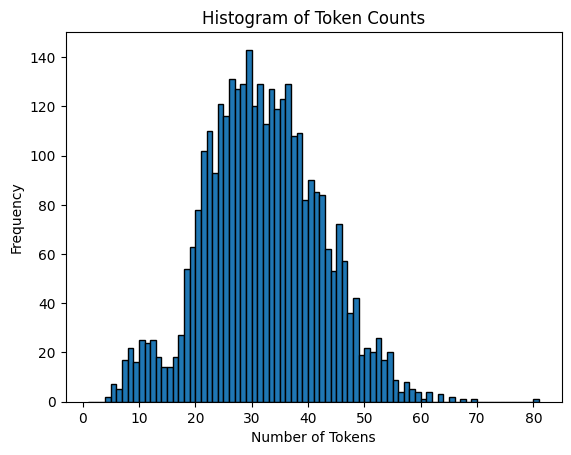

In [ ]:
import matplotlib.pyplot as plt

class TextAnalyzer:
    def __init__(self, sonar_t2v):
        self.sonar_t2v = sonar_t2v

    def analyze_texts(self, texts):
        sonar_tokenizer = sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')
        
        token_counts = []
        for text in texts:
            tokens = sonar_tokenizer(text)
            token_count = len(tokens)
            token_counts.append(token_count)

        plt.hist(token_counts, bins=range(1, max(token_counts) + 1), edgecolor='black')
        plt.title('Histogram of Token Counts')
        plt.xlabel('Number of Tokens')
        plt.ylabel('Frequency')
        plt.show()

analyzer = TextAnalyzer(sonar_t2v)
analyzer.analyze_texts(texts)

In [8]:
t = 'Humidity in the bathroom can cause towels to become damp, which can breed bacteria. What object in the bathroom can be used to hang the towel up to dry and avoid direct contact with the ground?'

In [11]:
len(sonar_t2v.tokenizer.create_encoder(lang='eng_Latn')(t))

48

## **BLASER**

In [27]:
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.models.blaser.loader import load_blaser_model

blaser = load_blaser_model("blaser_2_0_qe").eval()
text_embedder = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")

src_embs = text_embedder.predict(["The cat sat on the mat."], source_lang="eng_Latn")
mt_embs = text_embedder.predict(["The cat sat down on the carpet."], source_lang="eng_Latn")
print(blaser(src=src_embs, mt=mt_embs).item())  # 4.708


Using the cached checkpoint of blaser_2_0_qe. Set `force` to `True` to download again.


4.8331217765808105


In [34]:
import pandas as pd
from tqdm import tqdm
import torch

def get_blaser_score(src, mt, text_embedder=text_embedder):
    src_embs = text_embedder.predict([src], source_lang="eng_Latn")
    mt_embs = text_embedder.predict([mt], source_lang="eng_Latn")
    return blaser(src=src_embs, mt=mt_embs).item()

file_path = '/home/jovyan/zinkovich/ref-seg-text-break/experiments-old/lisa-explanatory/improved-sonar/improved-sonar-1/results_sample=1.csv'
data = pd.read_csv(file_path)

scores = []
for index, row in tqdm(data.iterrows()):
    adv_text = row['adv_text']
    orig_text = row['orig_text']
    score = get_blaser_score(src=orig_text, mt=adv_text, text_embedder=text_embedder)
    scores.append((adv_text, orig_text, score))

scores_df = pd.DataFrame(scores, columns=['adv_text', 'orig_text', 'b_score'])

sorted_scores = scores_df.sort_values(by='b_score', ascending=False)

29it [00:04,  6.51it/s]


In [36]:
sorted_scores.to_csv('sorted_scores.csv', index=False)

## **Random perturbations**

In [2]:
import sonar
from sonar.inference_pipelines.text import TextToEmbeddingModelPipeline
from sonar.inference_pipelines.text import EmbeddingToTextModelPipeline

sonar_t2v = TextToEmbeddingModelPipeline(encoder="text_sonar_basic_encoder", tokenizer="text_sonar_basic_encoder")
sonar_v2t = EmbeddingToTextModelPipeline(decoder="text_sonar_basic_decoder", tokenizer="text_sonar_basic_encoder")

In [3]:
text = 'the food with high protein'
embedding = sonar_t2v.predict([text], source_lang="eng_Latn")
embedding = embedding.clone().requires_grad_(True)

In [19]:
from tqdm import tqdm

embs_norms = []
for text in tqdm(texts):
    embedding = sonar_t2v.predict([text], source_lang="eng_Latn")
    embs_norms.append(embedding.norm().item())

100%|██████████| 3408/3408 [03:58<00:00, 14.29it/s]


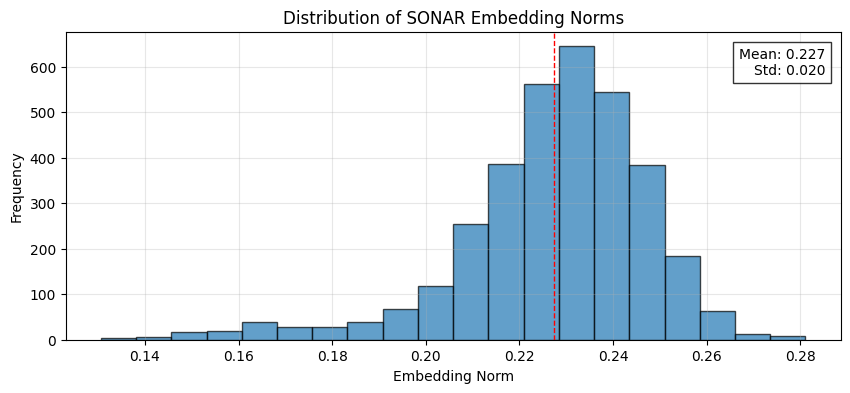

In [21]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10, 4))
plt.hist(embs_norms, bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of SONAR Embedding Norms')
plt.xlabel('Embedding Norm')
plt.ylabel('Frequency')

mean_norm = np.mean(embs_norms)
std_norm = np.std(embs_norms)
plt.axvline(mean_norm, color='red', linestyle='dashed', linewidth=1)
plt.text(0.98, 0.95, f'Mean: {mean_norm:.3f}\nStd: {std_norm:.3f}', 
         transform=plt.gca().transAxes, 
         horizontalalignment='right',
         verticalalignment='top',
         bbox=dict(facecolor='white', alpha=0.8))

plt.grid(True, alpha=0.3)
plt.savefig('sonar_embeddings_norms.png')
plt.show()

In [4]:
import torch

random_direction = torch.randn_like(embedding)
random_direction = random_direction / torch.norm(random_direction, dim=-1, keepdim=True)

perturbation = 0.05 * random_direction

modified_embedding = embedding + perturbation

In [7]:
import torch
import numpy as np

distances = [0.05, 0.06, 0.07, 0.08, 0.09, 0.10, 0.15, 0.20, 0.25, 0.30]
N = 5
print("Original text:", text)
print("\nPerturbed versions:")

for dist in distances:
    print(f"\nDistance = {dist:.2f}:")
    
    for _ in range(N):
        random_direction = torch.randn_like(embedding)
        random_direction = random_direction / torch.norm(random_direction, dim=-1, keepdim=True)
        
        perturbation = dist * random_direction
        
        modified_embedding = embedding + perturbation
        
        actual_dist = torch.norm(modified_embedding - embedding).item()
        
        reconstructed, _ = sonar_v2t.predict(modified_embedding, target_lang="eng_Latn", max_seq_len=512)
        print(f"  {reconstructed[0]} (actual distance: {actual_dist:.3f})")

Original text: the food with high protein

Perturbed versions:

Distance = 0.05:
  the food with high protein (actual distance: 0.050)
  the food with high protein (actual distance: 0.050)
  the food with high protein (actual distance: 0.050)
  the food with high protein (actual distance: 0.050)
  the food with high protein (actual distance: 0.050)

Distance = 0.06:
  the food with high protein (actual distance: 0.060)
  the food with high protein (actual distance: 0.060)
  the food with high protein (actual distance: 0.060)
  the food with high protein (actual distance: 0.060)
  the food with high protein (actual distance: 0.060)

Distance = 0.07:
  the food with high protein (actual distance: 0.070)
  the high- rich food (actual distance: 0.070)
  the food with high protein (actual distance: 0.070)
  the food with high protein (actual distance: 0.070)
  the food with high protein (actual distance: 0.070)

Distance = 0.08:
  the food with high protein (actual distance: 0.080)
  the fo

In [6]:
embedding.norm()

tensor(0.1700, grad_fn=<LinalgVectorNormBackward0>)

In [12]:
import json

file_path = '/home/jovyan/zinkovich/ref-seg-text-break/dataset/llm-seg40k/train.json'

with open(file_path, 'r') as file:
    data = json.load(file)
    length = len(data)
length

11336

In [13]:
file_path = '/home/jovyan/zinkovich/ref-seg-text-break/dataset/llm-seg40k/validation.json'

with open(file_path, 'r') as file:
    data = json.load(file)
    length = len(data)
length

1000

In [14]:
data

{'000000119210.jpg': {'from_dataset': 'coco',
  'qa_pairs': [{'question_id': '593bd455f9fb4d3ca0242f7d29dba767',
    'question': 'What animal is prominently seen in the image, known for its distinct black and white stripes?',
    'answer': 'zebra',
    'segmentation_path': '/home/leikel/junchi/lisa_dataset/reasoncoco/training_mixed/visualize/000000119210_1_mask.png',
    'rle_seg': {'size': [480, 640],
     'counts': '`ik14g>9I5L4L3M4L4K4M3M3N1N3N1N3N1N2O1O2M3M2N2N101N2N2N2N101N3M2N100O1`NeM[F\\2e9jMTFX2m9jMoET2U:mMREC>_2d:nMkDE>_2i:RNTEo1n:QNnDR2j:WNSEj1n:S12O2M3M2N2O2M0010O01O010O00100O010O1O10O010000O10000O1O2O0O100O100O2O0O1O1O1O101O00000O11O10O0001O00100O001O10O01O1O00100O1O001O100O001O100O1O1O100O001O1O100O1O00100O001O100O2N101N2N2N2O0O2N2N2O1N2N1O2O0O1O1O100O1O100O1O1O1O100O1O1O4L4M2M2N2N2N2O1N1O2O1mIgJ[2[5bMfJ_2[5]MgJc2\\5XMfJi2[5TMgJk2[5QMgJP3Z5mLgJT3[5gLgJY3]5aLeJ`3^5ZLdJi3]5RLdJo3b5iK_JW4i5aKWJ`4k5\\KVJe4l5WKUJi4n5RKTJQ5l5kJUJV5Q6bJPJ]5W6\\JjId5^6lIjIT6a700001O000O2N1AcIZH_6